  DECISION TREE REGRESSOR — HOUSE PRICE PREDICTION

Dataset created: 500 samples, 7 columns

--- First 5 rows ---
 Area_sqft  Bedrooms  Bathrooms  Age_years  Garage_spaces  Distance_CBD    Price
      3674         4          3          9              1         26.08 431000.0
      1360         2          2         48              1         18.65 153000.0
      1794         3          2         46              1         15.70 223000.0
      1630         4          3         11              1          5.62 261000.0
      1595         5          3         15              2          2.83 301000.0

--- Summary Statistics ---
       Area_sqft  Bedrooms  Bathrooms  Age_years  Garage_spaces  Distance_CBD      Price
count     500.00    500.00     500.00     500.00         500.00        500.00     500.00
mean     2319.38      3.05       2.00      24.72           0.97         15.21  292384.00
std      1003.67      1.46       0.82      14.11           0.81          8.41  126360.16
min       501.00

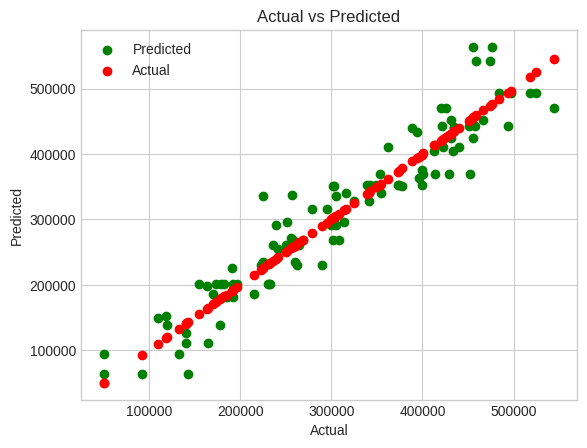

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


# ─────────────────────────────────────────────
# 1. DATASET CREATION
# ─────────────────────────────────────────────
np.random.seed(42)
n_samples = 500

print("=" * 60)
print("  DECISION TREE REGRESSOR — HOUSE PRICE PREDICTION")
print("=" * 60)

# Simulate a house pricing dataset
area         = np.random.randint(500, 4000, n_samples)           # sq ft
bedrooms     = np.random.randint(1, 6, n_samples)
bathrooms    = np.random.randint(1, 4, n_samples)
age          = np.random.randint(0, 50, n_samples)               # years old
garage       = np.random.randint(0, 3, n_samples)                # garage spaces
distance_cbd = np.random.uniform(1, 30, n_samples)               # km from city centre

# Price formula (non-linear, tree-friendly)
price = (
    area * 120
    + bedrooms * 15000
    + bathrooms * 10000
    - age * 800
    + garage * 12000
    - distance_cbd * 3000
    + np.random.normal(0, 20000, n_samples)          # noise
)
price = np.maximum(price, 50000)                     # floor at $50k

df = pd.DataFrame({
    'Area_sqft':     area,
    'Bedrooms':      bedrooms,
    'Bathrooms':     bathrooms,
    'Age_years':     age,
    'Garage_spaces': garage,
    'Distance_CBD':  distance_cbd.round(2),
    'Price':         price.round(-3),
})

print(f"\nDataset created: {df.shape[0]} samples, {df.shape[1]} columns")
print("\n--- First 5 rows ---")
print(df.head().to_string(index=False))
print("\n--- Summary Statistics ---")
print(df.describe().round(2).to_string())

# ─────────────────────────────────────────────
# 2. PREPROCESSING & SPLIT
# ─────────────────────────────────────────────
X = df.drop('Price', axis=1)
y = df['Price']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

# ─────────────────────────────────────────────
# 3. TRAIN DECISION TREE (multiple depths for comparison)
# ─────────────────────────────────────────────
depths    = [2, 4, 6, 8, None]
train_r2  = []
test_r2   = []
train_mse = []
test_mse  = []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_r2.append(r2_score(y_train, model.predict(X_train)))
    test_r2.append(r2_score(y_test,  model.predict(X_test)))
    train_mse.append(mean_squared_error(y_train, model.predict(X_train)))
    test_mse.append(mean_squared_error(y_test,  model.predict(X_test)))

# Best model (depth=6)
best_model = DecisionTreeRegressor(max_depth=6, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("\n" + "─" * 40)
print("  BEST MODEL METRICS (max_depth=6)")
print("─" * 40)
print(f"  R²   : {r2:.4f}")
print(f"  RMSE : ${rmse:,.0f}")
print(f"  MAE  : ${mae:,.0f}")
print(f"  MSE  : {mse:,.0f}")

plt.scatter(y_test,y_pred,color='green',label='Predicted')
plt.scatter(y_test,y_test,color='red',label='Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()